# 02 - Visualize CAMUS Images and Masks

Questions I should be able to answer after this notebook:

1. What does one CAMUS ultrasound image look like?
2. What does the corresponding ground-truth mask look like?
3. What are the label values inside the mask?
4. How can I overlay the mask on the original image?
5. Why does visualization help us understand semantic segmentation?

## 1. Big Picture

In the previous notebook, we inspected the CAMUS folder structure and metadata.

In this notebook, we visually inspect one image-mask pair:

```text
image = patient0001_2CH_ED.nii.gz
mask  = patient0001_2CH_ED_gt.nii.gz
```

The image is a grayscale ultrasound image. The mask is not a normal grayscale image. It is a class-label map where each pixel stores a category ID.

## 2. Import Basic Tools

We use basic Python tools, numpy, and matplotlib. No model training is involved.

In [1]:
from pathlib import Path
import gzip
import struct

import numpy as np
import matplotlib.pyplot as plt

## 3. Locate the Dataset

The function below searches upward from the current notebook location until it finds the `Resources` folder. This makes the notebook less sensitive to where Jupyter was launched from.

In [2]:
def find_project_root():
    """Find the CV_project folder that contains the CAMUS Resources directory."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    candidates.append(Path("/Users/felix/Downloads/CV_project"))

    for candidate in candidates:
        data_root = candidate / "Resources" / "database_nifti"
        split_root = candidate / "Resources" / "database_split"
        if data_root.exists() and split_root.exists():
            return candidate

    raise FileNotFoundError(
        "Could not find CAMUS Resources. Please check that CV_project/Resources exists."
    )


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "Resources" / "database_nifti"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "visualizations"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT exists:", DATA_ROOT.exists(), DATA_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

PROJECT_ROOT: /Users/felix/Downloads/CV_project
DATA_ROOT exists: True /Users/felix/Downloads/CV_project/Resources/database_nifti
OUTPUT_ROOT: /Users/felix/Downloads/CV_project/outputs/visualizations


## 4. Helper Function: Load a NIfTI Array

This is the same idea as in notebook 01. We manually read the compressed NIfTI file and convert it into a numpy array.

In a formal training project, we can replace this with `nibabel` or `SimpleITK`.

In [3]:
def load_nii_array(path):
    """Load a simple .nii.gz file into a numpy array."""
    raw = gzip.open(path, "rb").read()
    endian = "<" if struct.unpack("<i", raw[:4])[0] == 348 else ">"
    dim = struct.unpack(endian + "8h", raw[40:56])
    datatype = struct.unpack(endian + "h", raw[70:72])[0]
    vox_offset = int(struct.unpack(endian + "f", raw[108:112])[0])

    dtype_map = {
        2: np.uint8,
        4: np.int16,
        8: np.int32,
        16: np.float32,
        64: np.float64,
        256: np.int8,
        512: np.uint16,
        768: np.uint32,
    }

    shape = tuple(reversed(dim[1:1 + dim[0]]))
    arr = np.frombuffer(raw[vox_offset:], dtype=dtype_map[datatype], count=int(np.prod(shape))).reshape(shape)
    return np.squeeze(arr)

## 5. Select One Image-Mask Pair

Start with one simple case:

```text
patient = patient0001
view    = 2CH
phase   = ED
```

This gives us one input image and its corresponding ground-truth mask.

In [4]:
patient_id = "patient0001"
view = "2CH"
phase = "ED"

patient_dir = DATA_ROOT / patient_id
image_path = patient_dir / f"{patient_id}_{view}_{phase}.nii.gz"
mask_path = patient_dir / f"{patient_id}_{view}_{phase}_gt.nii.gz"

print("image_path:", image_path)
print("mask_path:", mask_path)
print("image exists:", image_path.exists())
print("mask exists:", mask_path.exists())

image_path: /Users/felix/Downloads/CV_project/Resources/database_nifti/patient0001/patient0001_2CH_ED.nii.gz
mask_path: /Users/felix/Downloads/CV_project/Resources/database_nifti/patient0001/patient0001_2CH_ED_gt.nii.gz
image exists: True
mask exists: True


## 6. Load Image and Mask

Now load the two files as arrays and inspect their shapes and values.

In [5]:
image = load_nii_array(image_path)
mask = load_nii_array(mask_path).astype(np.int64)

print("image shape:", image.shape)
print("image dtype:", image.dtype)
print("image min/max:", float(image.min()), float(image.max()))

print("\nmask shape:", mask.shape)
print("mask dtype:", mask.dtype)
print("mask labels:", np.unique(mask).tolist())

image shape: (389, 549)
image dtype: float32
image min/max: 0.0 255.0

mask shape: (389, 549)
mask dtype: int64
mask labels: [0, 1, 2, 3]


Key observation:

```text
image values = grayscale ultrasound intensity values
mask values  = discrete class labels
```

For this project, we only assume label `1` is the LV mask because the provided CAMUS EF notebook uses `lv_label = 1`. We will avoid making strong assumptions about labels `2` and `3` until we verify the exact label mapping.

## 7. Count Pixels for Each Mask Label

This helps us understand class imbalance. In segmentation, the background class often has many more pixels than the anatomical structures.

In [6]:
labels, counts = np.unique(mask, return_counts=True)
total_pixels = mask.size

for label, count in zip(labels, counts):
    percentage = 100 * count / total_pixels
    print(f"label {label}: {count} pixels ({percentage:.2f}%)")

label 0: 151914 pixels (71.13%)
label 1: 28841 pixels (13.50%)
label 2: 22177 pixels (10.38%)
label 3: 10629 pixels (4.98%)


## 8. Helper Functions for Visualization

The raw image is displayed as grayscale. The mask is converted into colors so that different labels are easy to see.

In [7]:
LABEL_COLORS = {
    0: (0, 0, 0),          # background
    1: (255, 60, 60),      # label 1, LV in the provided EF notebook
    2: (60, 220, 80),      # label 2
    3: (60, 140, 255),     # label 3
}


def normalize_to_uint8(arr):
    """Normalize an image array to uint8 values in [0, 255]."""
    arr = arr.astype(np.float32)
    arr = arr - arr.min()
    denominator = max(float(arr.max()), 1e-6)
    arr = arr / denominator
    return (arr * 255).astype(np.uint8)


def colorize_mask(mask):
    """Convert a class-label mask into an RGB color image."""
    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for label, color in LABEL_COLORS.items():
        color_mask[mask == label] = color
    return color_mask


def make_overlay(image, mask, alpha=0.45):
    """Overlay the color mask on top of the grayscale image."""
    gray = normalize_to_uint8(image)
    gray_rgb = np.stack([gray, gray, gray], axis=-1)
    color_mask = colorize_mask(mask)

    overlay = gray_rgb.copy()
    foreground = mask > 0
    overlay[foreground] = (
        (1 - alpha) * overlay[foreground] + alpha * color_mask[foreground]
    ).astype(np.uint8)
    return overlay

## 9. Visualize Image, Mask, and Overlay

The three panels below show:

1. the original ultrasound image,
2. the ground-truth mask,
3. the overlay of image and mask.

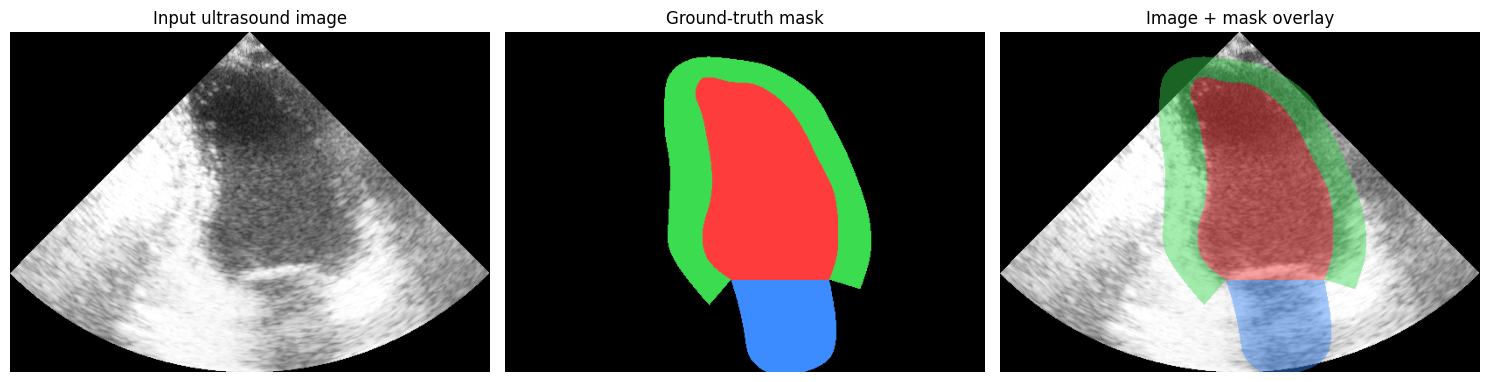

In [8]:
gray = normalize_to_uint8(image)
color_mask = colorize_mask(mask)
overlay = make_overlay(image, mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Input ultrasound image")
axes[0].axis("off")

axes[1].imshow(color_mask)
axes[1].set_title("Ground-truth mask")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Image + mask overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

This visualization makes the segmentation task concrete:

```text
The model sees the left panel as input.
The model needs to learn to predict the middle panel.
The right panel helps us visually check whether the mask aligns with the ultrasound anatomy.
```

## 10. Save the Visualization

Saving figures is useful for reports and meeting slides.

In [9]:
output_path = OUTPUT_ROOT / f"{patient_id}_{view}_{phase}_image_mask_overlay.png"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax in axes:
    ax.axis("off")

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Input ultrasound image")

axes[1].imshow(color_mask)
axes[1].set_title("Ground-truth mask")

axes[2].imshow(overlay)
axes[2].set_title("Image + mask overlay")

plt.tight_layout()
plt.savefig(output_path, dpi=160, bbox_inches="tight")
plt.close(fig)

print("Saved to:", output_path)

Saved to: /Users/felix/Downloads/CV_project/outputs/visualizations/patient0001_2CH_ED_image_mask_overlay.png


## 11. Compare ED and ES

ED means end-diastole, when the ventricle is relatively large. ES means end-systole, when the ventricle is relatively small.

Visualizing both phases helps us understand why ED and ES are important for ejection fraction estimation.

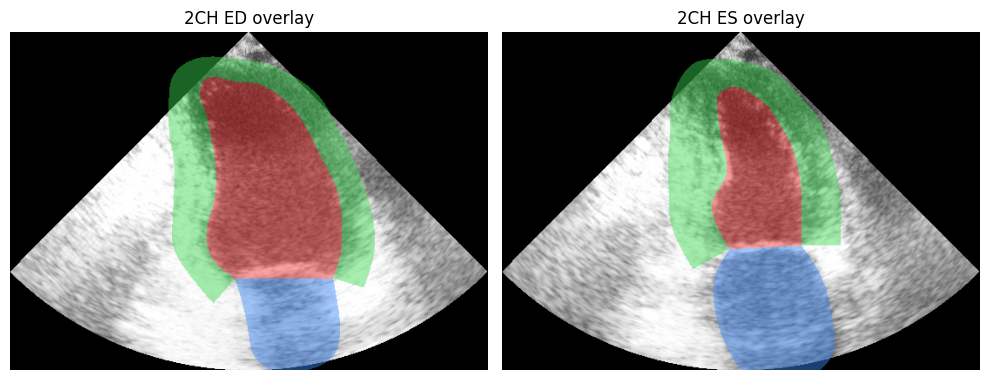

In [10]:
def load_pair(patient_id, view, phase):
    patient_dir = DATA_ROOT / patient_id
    image_path = patient_dir / f"{patient_id}_{view}_{phase}.nii.gz"
    mask_path = patient_dir / f"{patient_id}_{view}_{phase}_gt.nii.gz"
    image = load_nii_array(image_path)
    mask = load_nii_array(mask_path).astype(np.int64)
    return image, mask


ed_image, ed_mask = load_pair(patient_id, view="2CH", phase="ED")
es_image, es_mask = load_pair(patient_id, view="2CH", phase="ES")

ed_overlay = make_overlay(ed_image, ed_mask)
es_overlay = make_overlay(es_image, es_mask)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(ed_overlay)
axes[0].set_title("2CH ED overlay")
axes[0].axis("off")

axes[1].imshow(es_overlay)
axes[1].set_title("2CH ES overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 12. What I Learned

Summary in my own words:

1. A CAMUS input image is a grayscale ultrasound image.
2. The ground-truth mask is a class-label map with the same height and width as the image.
3. The mask contains discrete labels such as `0`, `1`, `2`, and `3`.
4. Overlaying the mask on the image helps verify that the annotation aligns with cardiac structures.
5. This confirms that the project is semantic segmentation: the model must predict a class for every pixel.

## 13. Questions I Still Have

1. What exactly do labels `2` and `3` correspond to anatomically?
2. How should we handle poor-quality ultrasound images during training?
3. Should ED and ES be trained as separate samples or modeled together?
4. Should 2CH and 4CH views be trained together or separately?
5. How should we evaluate whether a predicted mask is good?

## 14. Short Explanation for Meeting

Possible explanation for a meeting:

> I visualized one CAMUS image-mask pair to understand the actual segmentation target. The input is a grayscale cardiac ultrasound image, while the ground-truth file is a class-label mask with the same spatial size. The mask contains discrete pixel labels rather than intensity values. By overlaying the mask on the ultrasound image, I can see that the annotation corresponds to cardiac structures. This confirms that the model needs to solve a semantic segmentation problem, where each pixel is assigned a structure class.